#### To implement the Simple Linear Regression and predict the height of the person based on its weight

#### Step 1: Import  all the necessary libraries

In [443]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

#### Step 2: Load the dataset

In [444]:
df = pd.read_csv("height-weight.csv")

print(df.head())

   Weight  Height
0      45     120
1      58     135
2      48     123
3      60     145
4      70     160


#### Observations :

The above dataset has weight as well as the height of the person. Based on the weights, we need to predict the height of the person.

##### Step 3: Perform the Data Exploration

In [445]:
print("The total length of the dataset is:", len(df))

The total length of the dataset is: 23


In [446]:
print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (23, 2)


In [447]:
print("Columns used in the dataset is:", df.columns)

Columns used in the dataset is: Index(['Weight', 'Height'], dtype='object')


In [448]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes
None


In [449]:
print(df.describe())

           Weight      Height
count   23.000000   23.000000
mean    73.826087  158.391304
std     17.872407   19.511626
min     45.000000  120.000000
25%     59.000000  142.500000
50%     78.000000  162.000000
75%     86.000000  175.000000
max    105.000000  183.000000


In [450]:
print(df.corr()) 

          Weight    Height
Weight  1.000000  0.931142
Height  0.931142  1.000000


##### Observations:

1.   The correlation between the weight and the height is very high.

<Axes: >

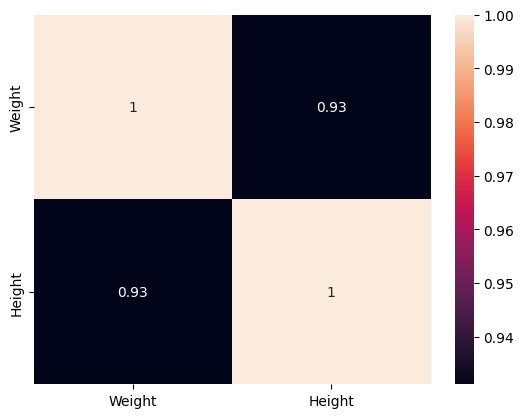

In [451]:
sns.heatmap(df.corr(), annot=True)

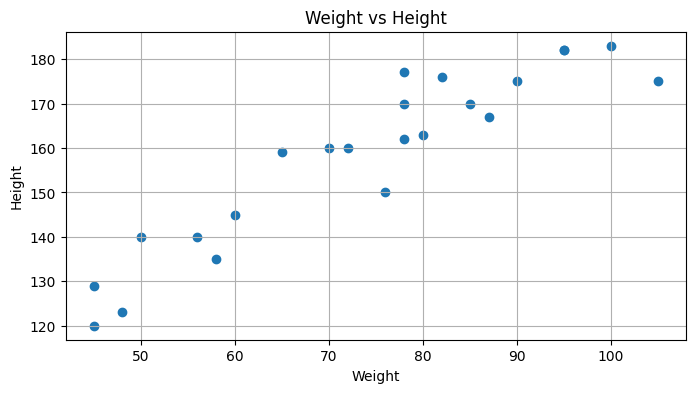

In [452]:
#### perform the scatter plot between the weight and the height
plt.figure(figsize=(8,4))
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title("Weight vs Height")
plt.grid(True)
plt.show()

##### Observations:

1.  With the increase in the weight, the height of the graph also increases. There is a linear relationship between the weight and the height of the graph.

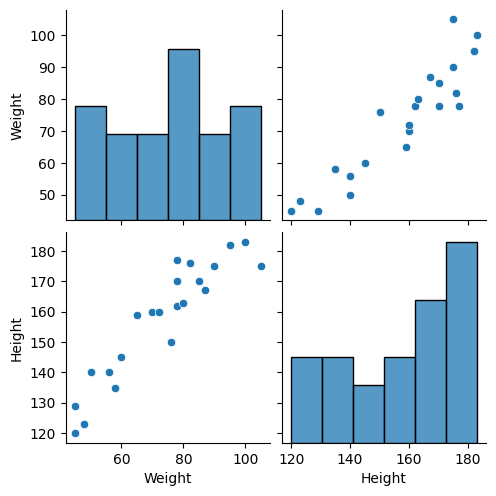

In [453]:
##### perform the pairwise distribution between all the numerical features

sns.pairplot(df)
plt.show()


##### Step 4: Perform the Data Cleaning

In [454]:
print(df.isnull().sum())

Weight    0
Height    0
dtype: int64


#### Observations:

1.  There are no NULL Values in the dataset.

In [455]:
print(df[df.duplicated()])

    Weight  Height
11      95     182


##### Observations:

1.  There is only one duplicate row in the dataset, so remove it.

In [456]:
df=df.drop_duplicates()

In [457]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Weight, Height]
Index: []


#####  Observations:

1.   Now there are no duplicate rows in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [458]:
X = df[['Weight']]

Y = df['Height']

In [459]:
print(X)

    Weight
0       45
1       58
2       48
3       60
4       70
5       78
6       80
7       90
8       95
9       78
10      82
12     105
13     100
14      85
15      78
16      50
17      65
18      76
19      87
20      45
21      56
22      72


In [460]:
print(Y)

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64


#### Step 6: Divide the independent and dependent variables into the training and testing data

In [461]:
from sklearn.model_selection  import  train_test_split

X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing data is:",X_test.shape)

print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing data is:" , Y_test.shape)

Shape of the input training data is: (17, 1)
Shape of the input testing data is: (5, 1)
Shape of the output training data is: (17,)
Shape of the output testing data is: (5,)


#### Step 7: Perform the Standard Scaling on the inputs

In [462]:
from  sklearn.preprocessing  import  StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

print("=================================Input Training data ========================================================")

print(X_train_scaled)

print("=================================Input Testing  data ========================================================")

print(X_test_scaled)

=================================Input Training data ========================================================
[[ 0.20608301]
 [-1.17025708]
 [ 1.89522766]
 [-0.92001342]
 [-0.2944043 ]
 [ 0.08096118]
 [ 1.58242309]
 [ 0.76913122]
 [-0.60720886]
 [-1.67074438]
 [ 0.20608301]
 [-0.16928247]
 [ 0.95681396]
 [ 0.45632666]
 [ 0.20608301]
 [-1.85842712]
 [ 0.33120483]]
=================================Input Testing  data ========================================================
[[-1.85842712]
 [ 0.6440094 ]
 [ 1.26961853]
 [-1.04513525]
 [-1.54562255]]


##### Step 8: Train the Simple Linear Regression Model

In [463]:
from sklearn.linear_model  import  LinearRegression

#### create an object for Linear Regression

lin = LinearRegression()


##### using the object for linear regression, train the model

lin.fit(X_train_scaled, Y_train)


LinearRegression()

#### Step 9: Predict the Model

In [464]:
Y_pred = lin.predict(X_test_scaled)

print(Y_pred)

[131.74187432 169.31717226 178.71099675 143.95384615 136.43878657]


#### Step 10: Calculate the slope and intercept of the model

In [465]:
print("Slope of the model is:", lin.coef_)
print("Intercept of the model is:", lin.intercept_)

Slope of the model is: [15.01548499]
Intercept of the model is: 159.64705882352942


##### Step 11: Evaluate the Regression Metrics

In [466]:
from  sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, Y_pred)
print("Mean Absolute error of the model is:", mae)


mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared error of the model is:", mse)


rmse = root_mean_squared_error(Y_test, Y_pred)
print("Root Mean Squared error of the model is:", rmse)


r2 = r2_score(Y_test, Y_pred)
print("R2 Score of the model is:", r2)

Mean Absolute error of the model is: 5.645752979414942
Mean Squared error of the model is: 48.401802156635064
Root Mean Squared error of the model is: 6.957140372066318
R2 Score of the model is: 0.9085792494774949


#### Observations:

1.    The R2 Score of the model is very high around 0.9085 . So the model is working fine.

#### Step 12:   plot Training data plot best fit line

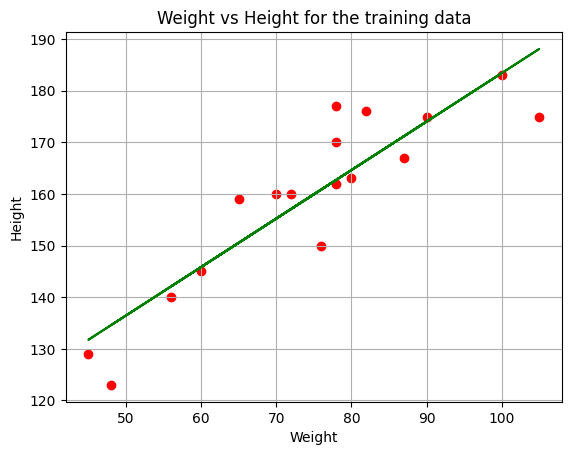

In [467]:
plt.scatter(X_train, Y_train, color = 'red')
plt.plot(X_train, lin.predict(X_train_scaled), color = 'green')
plt.title("Weight vs Height for the training data")
plt.xlabel("Weight")
plt.ylabel("Height")
plt.grid(True)
plt.show()

#### Step 13: plot Testing data plot best fit line

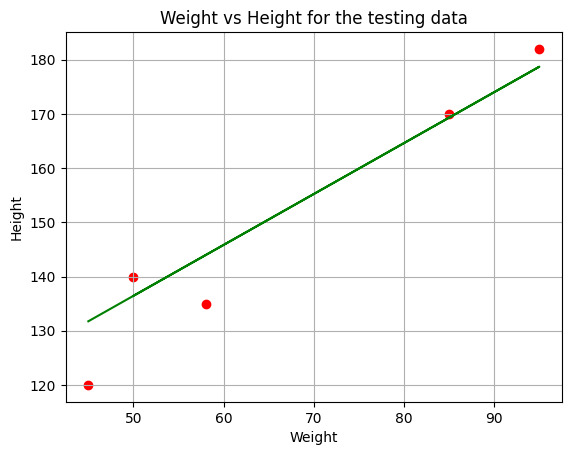

In [468]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, lin.predict(X_test_scaled), color = 'green')
plt.title("Weight vs Height for the testing data")
plt.xlabel("Weight")
plt.ylabel("Height")
plt.grid(True)
plt.show()

#### Step 14:  Perform the OLS

In [469]:
import  statsmodels.api as sm

model=sm.OLS(Y_train,X_train).fit()

prediction = model.predict(X_test_scaled)

print(prediction)

print(model.summary())

[-3.87403949  1.34248893  2.64662103 -2.17866775 -3.22197343]
                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.984
Model:                            OLS   Adj. R-squared (uncentered):              0.983
Method:                 Least Squares   F-statistic:                              1005.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):                    7.19e-16
Time:                        17:12:23   Log-Likelihood:                         -75.129
No. Observations:                  17   AIC:                                      152.3
Df Residuals:                      16   BIC:                                      153.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|    

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
